## [Luis Alejandro Rodríguez Arenas](https://luigitoby.github.io/)
## Cod. 202321287
# W07M3 - Evaluación 1 - Computacional


In [ ]:
import numpy as np
from numpy import deg2rad
from numpy import linspace
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, acos, asin,  latex, atan2, pprint, init_printing, Derivative, sqrt, rad, Eq, integrate, lambdify
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, init_vprinting, Point
# Configuración de impresión en formato LaTeX (MathJax)
init_vprinting(use_latex='mathjax')

# Ej1 (2 puntos)
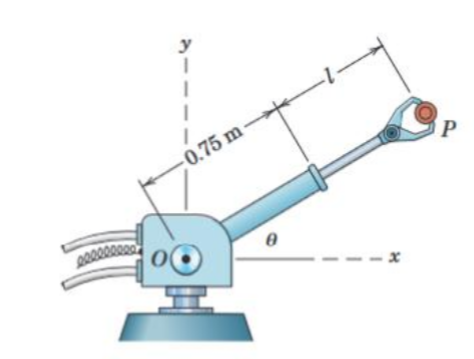 

Un robot opera recogiendo y moviendo objetos sobre una superficie. El robot
consta de un motor para controlar la rotación del brazo (𝜃) y un motor que permite extender
o retraer el brazo telescópico (𝑙).

# Ej1a
Encuentre las expresiones para describir la posición del efector del robot (P) en función del
movimiento del motor 𝜃 y de la longitud 𝑙.

In [2]:

theta, r = dynamicsymbols('theta r')
t = symbols('t')
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', (theta, N.z))

r1 = (0.75 + r)*A.x

v1 = r1.diff(t, N).express(N)


subs_dict = {   # En este caso no es necesario remplazar con los valores del parcial a mano
    r: 0.5,                 # m
    r.diff(t): 0.2,          # m/s
    r.diff(t,2): -0.3,        # m/s^2
    theta.diff(t): deg2rad(10),         # rad/s
    theta: deg2rad(30) 
}

v1.subs(subs_dict).express(N).simplify()
print("\nVelocidad simbólica:")
display(v1)
# print(f"magnitud de la velocidad es {v1.subs(subs_dict).express(N).simplify().magnitude()}")

a1 = v1.diff(t,N).express(N)
print("\nAceleración simbólica:")
display(a1)
# print(f"magnitud de la aceleracion es {a1.subs(subs_dict).express(N).simplify().magnitude()}")

# redefinir variables simbólicas para simplificar la impresión
l_dot, l_ddot, theta_dot, theta_ddot = symbols('l_dot l_ddot theta_dot theta_ddot')

simp_subs = {
    r.diff(t): l_dot,
    r.diff(t,2): l_ddot,
    theta.diff(t): theta_dot,
    theta.diff(t,2): theta_ddot
}

print("\nVelocidad simbólica simplificada:")
display(v1.subs(simp_subs))

print("\nAceleración simbólica simplificada:")
display(a1.subs(simp_subs))



Velocidad simbólica:


(-(r + 0.75)⋅sin(θ)⋅θ̇ + cos(θ)⋅ṙ) n_x + ((r + 0.75)⋅cos(θ)⋅θ̇ + sin(θ)⋅ṙ) n_y


Aceleración simbólica:


⎛                                          2                          ⎞        ↪
⎝-(r + 0.75)⋅sin(θ)⋅θ̈ - (r + 0.75)⋅cos(θ)⋅θ̇  - 2⋅sin(θ)⋅ṙ⋅θ̇ + cos(θ)⋅r̈⎠ n_x +  ↪

↪ ⎛                     2                                                ⎞    
↪ ⎝- (r + 0.75)⋅sin(θ)⋅θ̇  + (r + 0.75)⋅cos(θ)⋅θ̈ + sin(θ)⋅r̈ + 2⋅cos(θ)⋅ṙ⋅θ̇⎠ n_y


Velocidad simbólica simplificada:


(l_dot⋅cos(θ) - θ_dot⋅(r + 0.75)⋅sin(θ)) n_x + (l_dot⋅sin(θ) + θ_dot⋅(r + 0.75 ↪

↪ )⋅cos(θ)) n_y


Aceleración simbólica simplificada:


⎛                                                                 2            ↪
⎝l_ḋ⋅cos(θ) - 2⋅l_dot⋅θ_dot⋅sin(θ) - θ_ḋ⋅(r + 0.75)⋅sin(θ) - θ_dot ⋅(r + 0.75) ↪

↪        ⎞       ⎛                                                             ↪
↪ ⋅cos(θ)⎠ n_x + ⎝l_ḋ⋅sin(θ) + 2⋅l_dot⋅θ_dot⋅cos(θ) + θ_ḋ⋅(r + 0.75)⋅cos(θ) -  ↪

↪      2                  ⎞    
↪ θ_dot ⋅(r + 0.75)⋅sin(θ)⎠ n_y

# Ej1b
Usted programa su robot de forma de que L dependa de 𝜃 siguiendo la siguiente función:
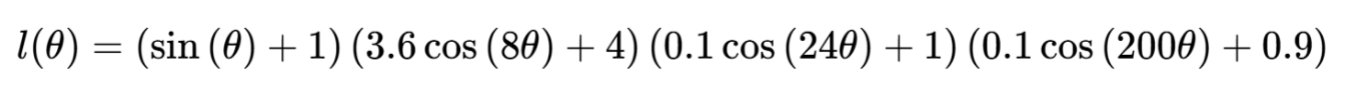
Grafique la trayectoria que haría el punto P (grafica x vs y), para una vuelta de 𝜃 entre [0, 2π].

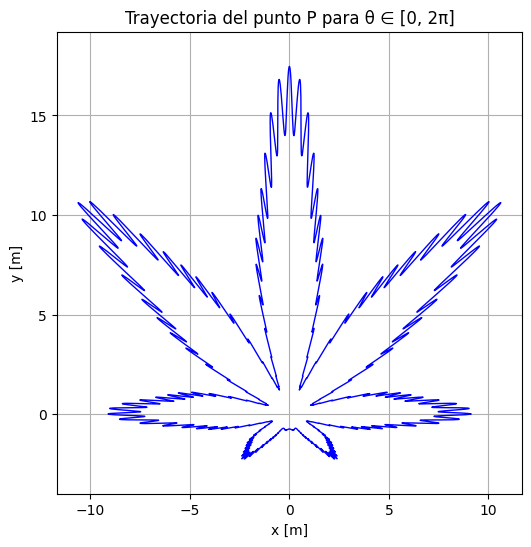

In [3]:
# Definición de la función l(theta), hago una función para poder usar lamdify, pero tambien tengo que usar cos y sin de np para que funcione 
def l_theta(theta):
    return (np.sin(theta) + 1) * (3.6*np.cos(8*theta) + 4) * (0.1*np.cos(24*theta) + 1) * (0.1*np.cos(200*theta) + 0.9)

# Rango de theta
theta_vals = np.linspace(0, 2*np.pi, 5000) 

# Coordenadas del efector (P)
l_vals = l_theta(theta_vals)
x_vals = (0.75 + l_vals) * np.cos(theta_vals)
y_vals = (0.75 + l_vals) * np.sin(theta_vals)

# Gráfica
plt.figure(figsize=(6,6))
plt.plot(x_vals, y_vals, 'b', linewidth=1)
plt.title("Trayectoria del punto P para θ ∈ [0, 2π]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True)
plt.show()


# Comentarios
* Curiosa la figura! jajaja

# Ej2 Rueda de feria (1 punto) 

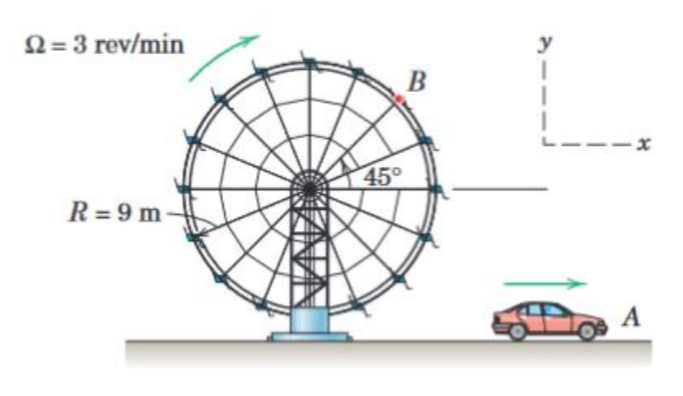

El automóvil (A) tiene una velocidad de 50km/h y frena produciendo una
desaceleración constante de 3m/s2. Determine la velocidad y aceleración del carro relativa a
un observador subido en la rueda de radio 9m que se mueve a 3rpm constantes cuando el
observador pasa por el punto B mostrado en la imagen (45°),

In [4]:

theta = dynamicsymbols('theta')
t = symbols('t')
r = 9 # m
w = pi/10
theta_val = deg2rad(45)
v_A_mag = 50*(1000/3600)
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', (theta, N.z))

v_A = (v_A_mag)*N.x

a_A = -3*N.x

v_B = -w*r*A.y

V_ab = v_A - v_B


V_ab_result = V_ab.express(N).subs({theta : theta_val}).simplify().evalf()

print("Resultado vectorial de la velocidad relativa V_a/b")
display(V_ab_result)
print("Magnitud de la velocidad en m/s")
display(V_ab_result.magnitude()) 
A_ab = a_A - (-(w**2)*r*A.x)
subs_dict = {
    theta: theta_val,
    theta.diff(t): w 
}

A_ab_res = A_ab.express(N).subs(subs_dict).simplify().evalf()

print("Resultado vectorial de la aceleración relativa V_a/b")
display(A_ab_res)
print("Magnitud de la velocidad en m/s^2")
display(A_ab_res.magnitude()) 

Resultado vectorial de la velocidad relativa V_a/b


11.8895915667176 n_x + 1.99929732217127 n_y

Magnitud de la velocidad en m/s


12.0565159729419

Resultado vectorial de la aceleración relativa V_a/b


-2.3719022220325 n_x + 0.628097777967499 n_y

Magnitud de la velocidad en m/s^2


2.45365583763706

# Ej3 Delizador (2.0 puntos) 

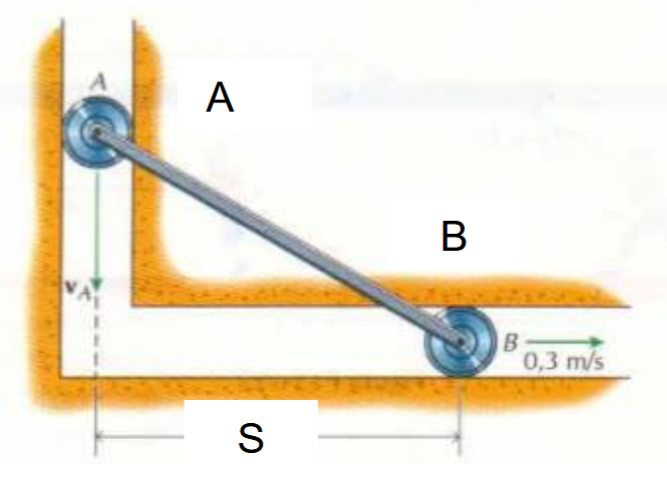

Los rodillos están unidos por una barra de 1.5m de longitud. El rodillo en B se
está moviendo a una velocidad constante de 0.3m/s. Grafique la velocidad Va en función de
s en el intervalo entre 0.25 y 1.0m.

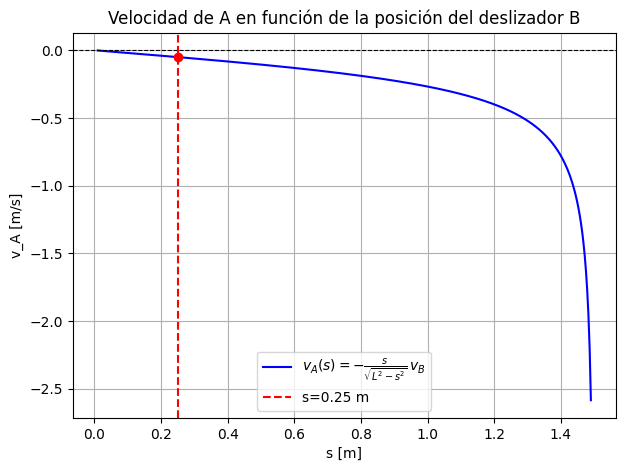

In [ ]:
# datos
L = 1.5   # longitud de la barra [m]
vB = 0.3  # velocidad de B [m/s]
s = symbols('s', real=True, positive=True)

# expresión simbólica de la velocidad de A
vA_expr = - s * vB / sqrt(L**2 - s**2) # La hice con punto de velocidad 0 porque es lo más sencillo

# convertir a función numérica para lambdifiarla
vA_func = lambdify(s, vA_expr, 'numpy')

# rango de s (entre 0 y L, excluyendo extremos para evitar singularidades)
s_vals = np.linspace(0.01, L-0.01, 400) # Note el L-0.01 para que no dividamos por 0 y todo se dañe
vA_vals = vA_func(s_vals)

# gráfica
plt.figure(figsize=(7,5))
plt.plot(s_vals, vA_vals, label=r'$v_A(s) = -\frac{s}{\sqrt{L^2-s^2}}\,v_B$', color='b') # < Esto es ChatGPT5 graficando, me parece que queda bonito entonces lo dejo
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axvline(0.25, color='r', linestyle='--', label='s=0.25 m')

# marcar el punto evaluado
plt.scatter([0.25], [vA_func(0.25)], color='r', zorder=5) # Verifico con el punto del parcial a mano para asegurarme que tiene sentido el resultado general.

# formato
plt.title("Velocidad de A en función de la posición del deslizador B")
plt.xlabel("s [m]")
plt.ylabel("v_A [m/s]")
plt.legend()
plt.grid(True)
plt.show()


# Ej4 (1 punto) 
La foto muestra un exprimidor de naranjas de uso manual cuyo funcionamiento se
da a través de un mecanismo que puede ser representado de forma planar.

# Ej4a
Realice el diagrama esquemático del mecanismo usando las convenciones de tierra,
revoluta y prismática vistas en clase. Sobre este diagrama defina marcos de referencia
convenientes. Incluya su diagrama en el cuaderno ipybn.

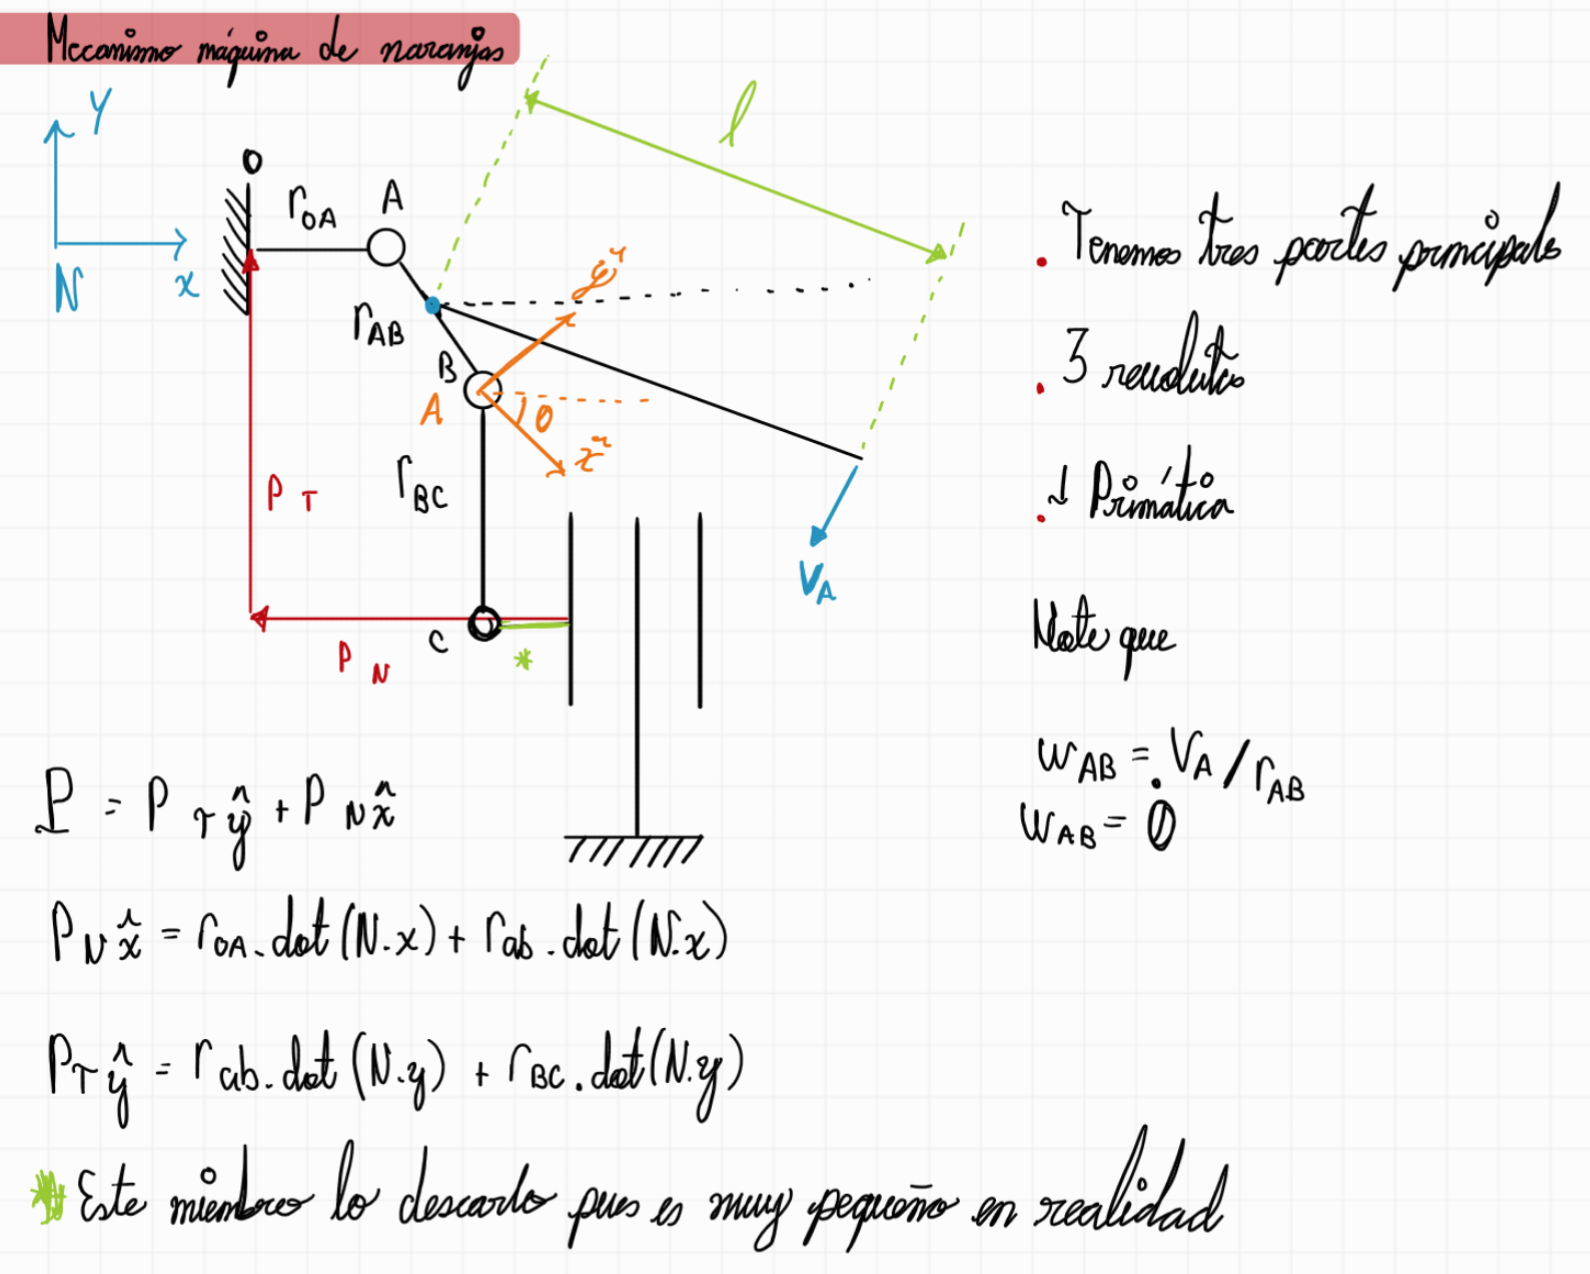

# Ej4b
A través de sus marcos de referencia, plantee la ecuación vectorial que describe el
movimiento del mecanismo. Incluya su diagrama en el cuaderno ipybn, identificando sobre
este, y de forma clara, las variables empleadas en su código. Presente sus ecuaciones
expresadas el marco de referencia global (tierra).

In [6]:
theta = dynamicsymbols('theta')
t, r_oa, r_ab, r_bc, V_a, l, theta_inicial = symbols('t r_oa, r_ab, r_bc V_a l theta_inicial')
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', (theta, N.z))

r1 = r_oa*N.x

r2 = r_ab*A.x

r3 = -r_bc*N.y

# Note que aunque tenemos 4 miembros, el miembro en verde en mi diagrama realmente no aporta a la cinemática del problema
# pues este va a ser muy pequeño en comparación a los demás, por lo tanto podemos simplificar el análisis al no tenerlo en cuenta (De hecho note que este
# elemento parece ir hacia adentro del papel en una representación planar del mecanismo, solamente que lo agrego por claridad mental y tener la union prismática
# unida a algo).

# Este es el vector que me devuelve a mi punto inicial (ground)

P_t = r1.dot(N.x)*N.x + r2.dot(N.x)*N.x

P_n = r2.dot(N.y)*N.y + r3.dot(N.y)*N.y

r4 = P_t + P_n

solu = r1+r2+r3+r4

sub = {
    theta : theta_inicial,
    theta.diff(t) : V_a/l
}

print(f"La ecuación que describe el movimiento del mecanísmo es:" )
display(solu.subs(sub).express(N))

# En este caso la velocidad angular se puede calcular de manera simple haciendo "palanca" con la parte del miembro que esta separada
# del miembro AB. l es la longitud de esta parte de la palanca


vel = solu.diff(t, N)

print("Ecuación de velocidad general:")
display(vel)

# Luego para la velocidad debemos encontrar thetadot y thetadotdot
print("Expresion de la velocidad del exprimidor en termino de la velocidad del brazo y el ángulo inicial:")
display(vel.subs(sub))


La ecuación que describe el movimiento del mecanísmo es:


(r_ab⋅cos(θ_inicial) + r_ab⋅cos(θ) + 2⋅rₒₐ) n_x + (r_ab⋅sin(θ_inicial) + r_ab⋅ ↪

↪ sin(θ) - 2⋅r_bc) n_y

Ecuación de velocidad general:


-2⋅r_ab⋅sin(θ)⋅θ̇ n_x + 2⋅r_ab⋅cos(θ)⋅θ̇ n_y

Expresion de la velocidad del exprimidor en termino de la velocidad del brazo y el ángulo inicial:


-2⋅Vₐ⋅r_ab⋅sin(θ_inicial)        2⋅Vₐ⋅r_ab⋅cos(θ_inicial)    
────────────────────────── n_x + ──────────────────────── n_y
            l                               l                